# MoMA Collection - Additional Exploratory Data Analysis

## Setup and Data Loading

In [113]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency
import warnings
warnings.filterwarnings('ignore')

# Set style
sns.set_style('whitegrid')
sns.set_palette('husl')
plt.rcParams['figure.figsize'] = (14, 7)

# Load datasets
artworks = pd.read_csv('../data/moma-collection/Artworks.csv')
artists = pd.read_csv('../data/moma-collection/Artists.csv')

print(f"Dataset Overview:")
print(f"Artworks: {len(artworks):,} records")
print(f"Artists: {len(artists):,} records")

Dataset Overview:
Artworks: 160,269 records
Artists: 15,807 records


## Data Cleaning

In [114]:
# Clean Artists dataset
artists = artists.drop(columns=['Wiki QID', 'ULAN'])
key_artist_columns = ['ArtistBio', 'Nationality', 'Gender', 'BeginDate']
artists_clean = artists.dropna(subset=key_artist_columns)

# Clean Artworks dataset
columns_to_drop = [
    'Dimensions', 'Height (cm)', 'Width (cm)', 'Depth (cm)', 
    'Circumference (cm)', 'Diameter (cm)', 'Length (cm)', 
    'Weight (kg)', 'Seat Height (cm)', 'Duration (sec.)',
    'AccessionNumber', 'CreditLine', 'Cataloged', 'OnView',
    'URL', 'ImageURL'
]

artworks = artworks.drop(columns=columns_to_drop)

key_artwork_columns = [
    'Title', 'Artist', 'ConstituentID', 'ArtistBio', 
    'Nationality', 'BeginDate', 'EndDate', 'Gender', 
    'Date', 'Medium', 'Classification', 'Department'
]

artworks_clean = artworks.dropna(subset=key_artwork_columns)

# Convert date to numeric
artworks_clean['Date_numeric'] = pd.to_numeric(artworks_clean['Date'], errors='coerce')
artworks_clean = artworks_clean.dropna(subset=['Date_numeric'])
artworks_clean['Decade'] = (artworks_clean['Date_numeric'] // 10 * 10).astype(int)

print(f"Cleaned Data:")
print(f"Artists: {len(artists_clean):,} records")
print(f"Artworks: {len(artworks_clean):,} records")

Cleaned Data:
Artists: 11,881 records
Artworks: 92,596 records


## Medium Analysis

Top 20 Mediums:
Total unique mediums: 16184

Gelatin silver print: 10,795 (11.7%)
Lithograph: 6,778 (7.3%)
Albumen silver print: 3,006 (3.2%)
Pencil on paper: 1,606 (1.7%)
Chromogenic print: 1,445 (1.6%)
Etching: 1,214 (1.3%)
Pencil on tracing paper: 1,126 (1.2%)
Ink on paper: 1,028 (1.1%)
Letterpress: 922 (1.0%)
Offset lithograph: 917 (1.0%)
Video (color, sound): 874 (0.9%)
Screenprint: 761 (0.8%)
Oil on canvas: 755 (0.8%)
Drypoint: 706 (0.8%)
Inkjet print: 676 (0.7%)
Woodcut: 577 (0.6%)
Gelatin silver printing-out-paper print: 499 (0.5%)
Lithograph, printed in color: 455 (0.5%)
Colored pencil, pencil, and ballpoint pen on board: 454 (0.5%)
Photogravure: 437 (0.5%)


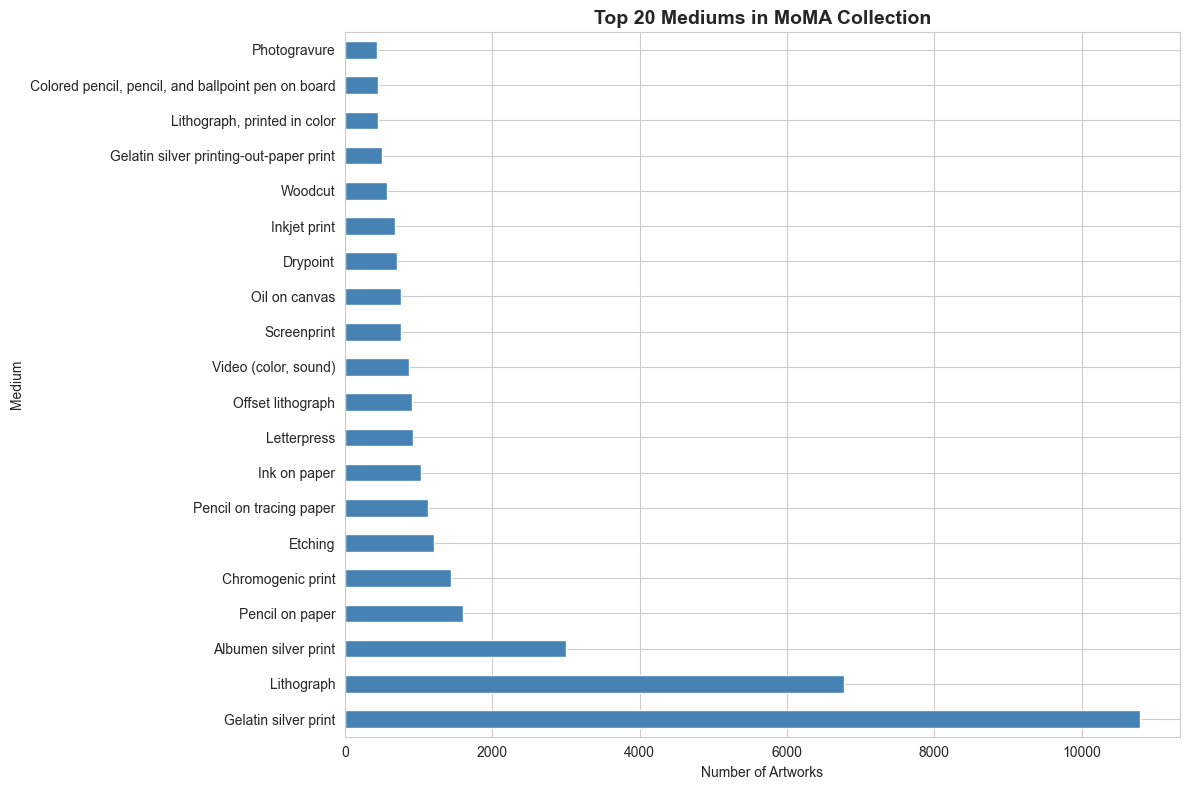


Top 20 mediums represent 37.8% of collection


In [115]:
# Top 20 mediums
top_mediums = artworks_clean['Medium'].value_counts().head(20)

print(f"Top 20 Mediums:")
print(f"Total unique mediums: {artworks_clean['Medium'].nunique()}")
print()
for medium, count in top_mediums.items():
    pct = (count / len(artworks_clean)) * 100
    print(f"{medium}: {count:,} ({pct:.1f}%)")

# Visualize
fig, ax = plt.subplots(figsize=(12, 8))
top_mediums.plot(kind='barh', ax=ax, color='steelblue')
ax.set_title('Top 20 Mediums in MoMA Collection', fontsize=14, fontweight='bold')
ax.set_xlabel('Number of Artworks')
ax.set_ylabel('Medium')
plt.tight_layout()
plt.show()

# Diversity index for mediums
medium_diversity = top_mediums.sum() / len(artworks_clean) * 100
print(f"\nTop 20 mediums represent {medium_diversity:.1f}% of collection")

## Classification Analysis

Art Classifications in MoMA:
Total unique classifications: 38

Print: 23,425 (25.3%)
Photograph: 22,116 (23.9%)
Illustrated Book: 13,567 (14.7%)
Drawing: 9,850 (10.6%)
Design: 7,800 (8.4%)
Mies van der Rohe Archive: 3,918 (4.2%)
Architecture: 2,769 (3.0%)
Video: 1,875 (2.0%)
Painting: 1,818 (2.0%)
Sculpture: 1,205 (1.3%)
Notebook: 911 (1.0%)
Multiple: 704 (0.8%)
Installation: 574 (0.6%)
Frank Lloyd Wright Archive: 444 (0.5%)
Audio: 399 (0.4%)
Periodical: 338 (0.4%)
Ephemera: 218 (0.2%)
Collage: 186 (0.2%)
Work on Paper: 119 (0.1%)
Film: 96 (0.1%)
(not assigned): 53 (0.1%)
Poster: 49 (0.1%)
Portfolio: 46 (0.0%)
Performance: 28 (0.0%)
Textile: 18 (0.0%)
Digital: 18 (0.0%)
Media: 17 (0.0%)
Wallpaper: 12 (0.0%)
Correspondence: 7 (0.0%)
Graphic Design: 3 (0.0%)
Photography Research/Reference: 3 (0.0%)
Website: 2 (0.0%)
Software: 2 (0.0%)
Publication: 2 (0.0%)
Film (object): 1 (0.0%)
Furniture and Interiors: 1 (0.0%)
Architectural Model: 1 (0.0%)
Document: 1 (0.0%)


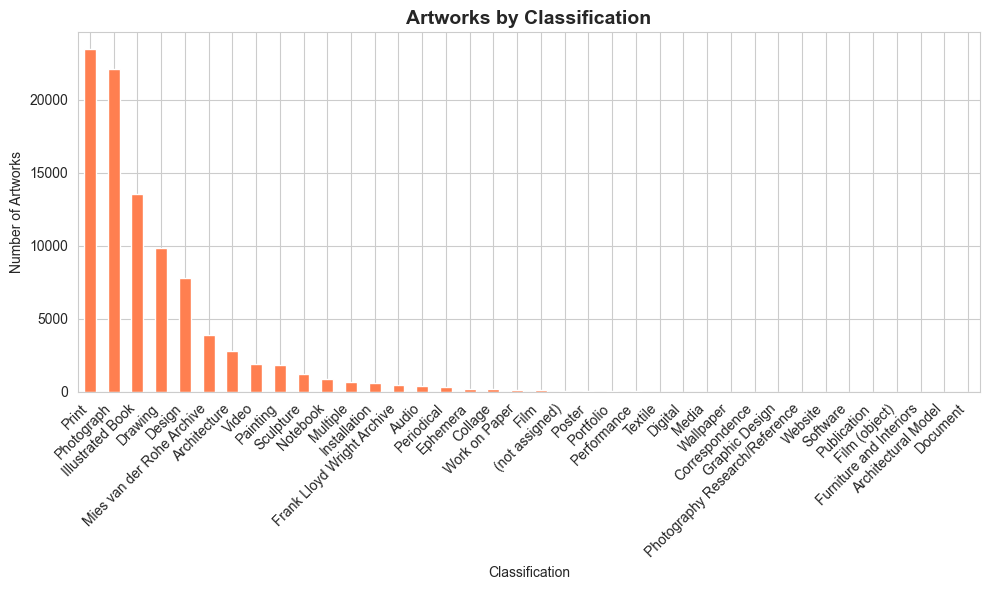

In [116]:
# Classification distribution
classifications = artworks_clean['Classification'].value_counts()

print(f"Art Classifications in MoMA:")
print(f"Total unique classifications: {len(classifications)}")
print()
for classification, count in classifications.items():
    pct = (count / len(artworks_clean)) * 100
    print(f"{classification}: {count:,} ({pct:.1f}%)")

# Visualize
fig, ax = plt.subplots(figsize=(10, 6))
classifications.plot(kind='bar', ax=ax, color='coral')
ax.set_title('Artworks by Classification', fontsize=14, fontweight='bold')
ax.set_xlabel('Classification')
ax.set_ylabel('Number of Artworks')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## Artist Prolificacy Analysis

Artist Prolificacy Statistics:
Mean works per artist: 8.63
Median works per artist: 1
Std Dev: 60.51
Min works: 1
Max works: 3330

Top 15 Most Prolific Artists:
Eugène Atget: 3,330 works
Ludwig Mies van der Rohe: 3,212 works
Louise Bourgeois: 2,665 works
Lee Friedlander: 1,234 works
Ellsworth Kelly: 1,063 works
Jean Dubuffet: 1,014 works
Lilly Reich: 686 works
Émile Bernard: 626 works
Sol LeWitt: 601 works
Pierre Bonnard: 577 works
Frédéric Bruly Bouabré: 478 works
Frank Lloyd Wright: 464 works
August Sander: 421 works
Jan Dibbets: 399 works
Pablo Picasso: 395 works


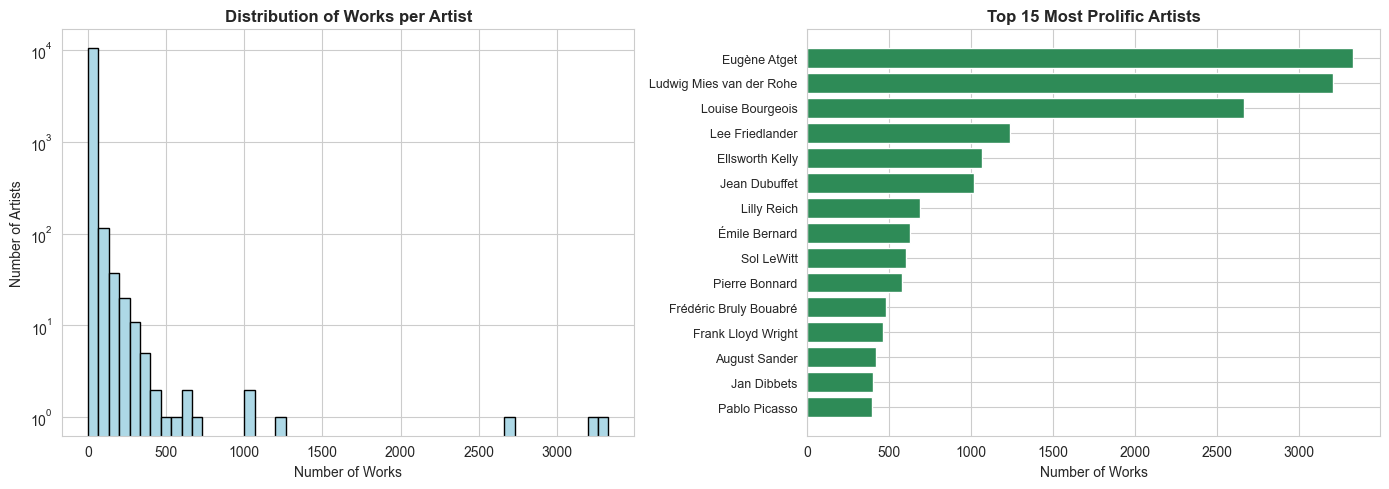


Concentration Analysis:
Top 1% of artists (107 artists) create 36.4% of artworks


In [117]:
# Works per artist
works_per_artist = artworks_clean.groupby('Artist').size().reset_index(name='Works_Count')
works_per_artist = works_per_artist.sort_values('Works_Count', ascending=False)

print(f"Artist Prolificacy Statistics:")
print(f"Mean works per artist: {works_per_artist['Works_Count'].mean():.2f}")
print(f"Median works per artist: {works_per_artist['Works_Count'].median():.0f}")
print(f"Std Dev: {works_per_artist['Works_Count'].std():.2f}")
print(f"Min works: {works_per_artist['Works_Count'].min()}")
print(f"Max works: {works_per_artist['Works_Count'].max()}")
print()
print(f"Top 15 Most Prolific Artists:")
for idx, row in works_per_artist.head(15).iterrows():
    print(f"{row['Artist']}: {row['Works_Count']:,} works")

# Distribution visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
axes[0].hist(works_per_artist['Works_Count'], bins=50, color='lightblue', edgecolor='black')
axes[0].set_title('Distribution of Works per Artist', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Number of Works')
axes[0].set_ylabel('Number of Artists')
axes[0].set_yscale('log')

# Top 15 artists
top_artists = works_per_artist.head(15)
axes[1].barh(range(len(top_artists)), top_artists['Works_Count'], color='seagreen')
axes[1].set_yticks(range(len(top_artists)))
axes[1].set_yticklabels(top_artists['Artist'], fontsize=9)
axes[1].set_title('Top 15 Most Prolific Artists', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Number of Works')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

# Concentration analysis
top_100_contribution = works_per_artist.head(100)['Works_Count'].sum()
print(f"\nConcentration Analysis:")
print(f"Top 1% of artists ({len(works_per_artist)//100} artists) create {(top_100_contribution / len(artworks_clean) * 100):.1f}% of artworks")

## Geographic Diversity Analysis

Geographic Diversity:
Total unique nationalities: 899

Top 15 Nationalities:
(American): 44,439 (48.0%)
(French): 12,040 (13.0%)
(German): 6,292 (6.8%)
(British): 3,728 (4.0%)
(Italian): 1,904 (2.1%)
(Japanese): 1,712 (1.8%)
(Spanish): 1,665 (1.8%)
(Swiss): 1,493 (1.6%)
(Russian): 1,439 (1.6%)
(Dutch): 1,232 (1.3%)
(Mexican): 1,140 (1.2%)
(American) (American): 829 (0.9%)
(Belgian): 765 (0.8%)
(Canadian): 684 (0.7%)
(Brazilian): 643 (0.7%)

Herfindahl Index (Geographic Concentration): 0.2560
(Range: 0 = perfect diversity, 1 = complete concentration)


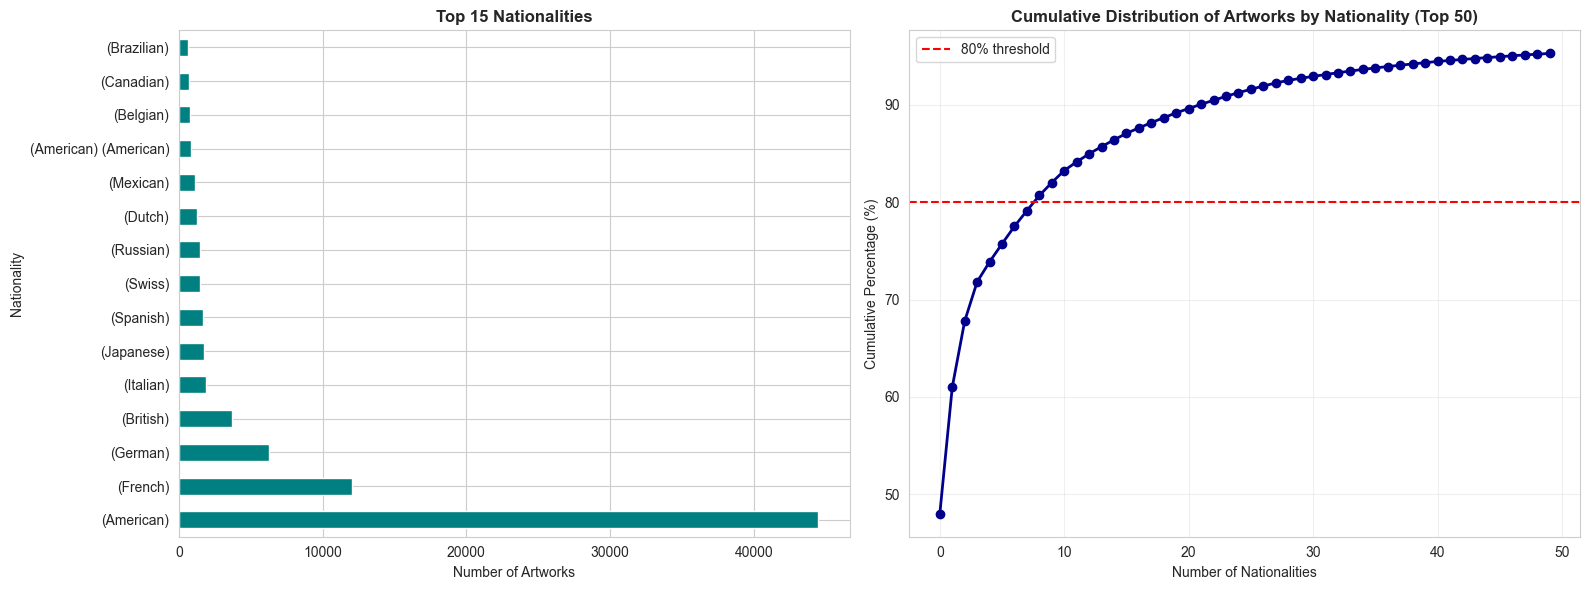

In [118]:
# Nationality statistics
nationality_stats = artworks_clean['Nationality'].value_counts()

print(f"Geographic Diversity:")
print(f"Total unique nationalities: {artworks_clean['Nationality'].nunique()}")
print(f"\nTop 15 Nationalities:")
for nationality, count in nationality_stats.head(15).items():
    pct = (count / len(artworks_clean)) * 100
    print(f"{nationality}: {count:,} ({pct:.1f}%)")

# Herfindahl index for geographic concentration
herfindahl = ((nationality_stats / nationality_stats.sum()) ** 2).sum()
print(f"\nHerfindahl Index (Geographic Concentration): {herfindahl:.4f}")
print(f"(Range: 0 = perfect diversity, 1 = complete concentration)")

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Top 15
nationality_stats.head(15).plot(kind='barh', ax=axes[0], color='teal')
axes[0].set_title('Top 15 Nationalities', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Number of Artworks')

# Concentration
cumsum = nationality_stats.cumsum() / nationality_stats.sum() * 100
axes[1].plot(range(len(cumsum.head(50))), cumsum.head(50).values, marker='o', linewidth=2, color='darkblue')
axes[1].axhline(y=80, color='red', linestyle='--', label='80% threshold')
axes[1].set_title('Cumulative Distribution of Artworks by Nationality (Top 50)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Number of Nationalities')
axes[1].set_ylabel('Cumulative Percentage (%)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Medium Preferences

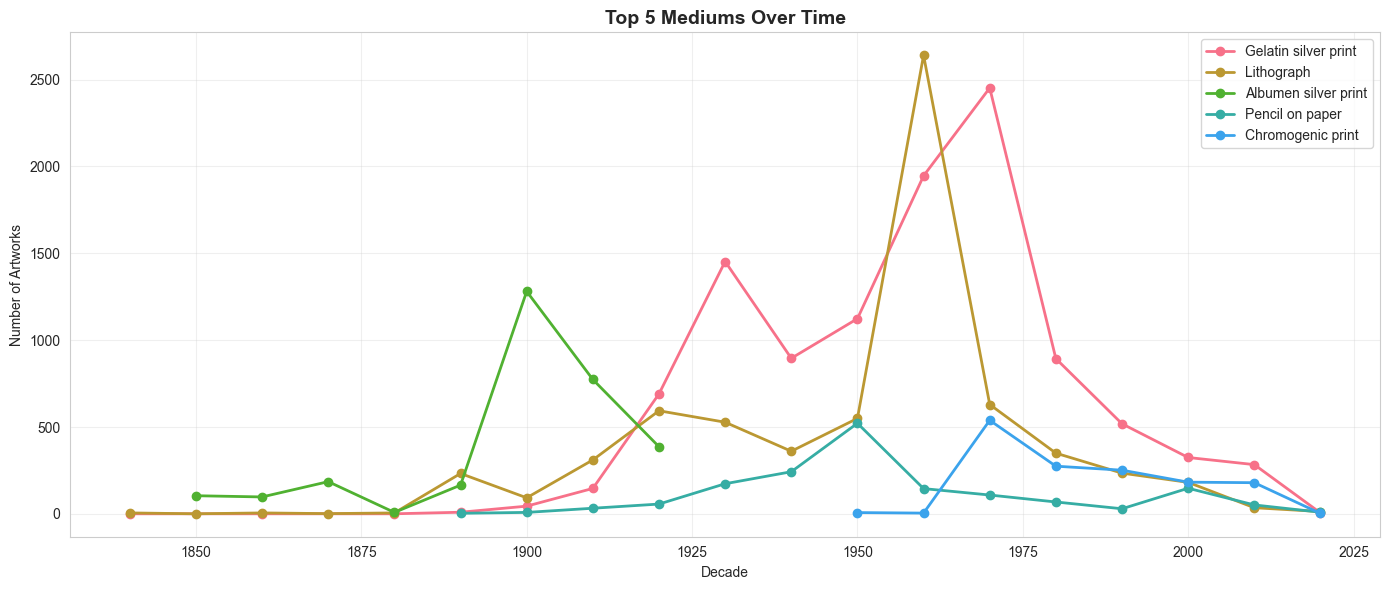

In [119]:
# Top mediums by decade
top_mediums_all = artworks_clean['Medium'].value_counts().head(8).index

fig, ax = plt.subplots(figsize=(14, 6))

for medium in list(top_mediums_all)[:5]:
    medium_decade = artworks_clean[artworks_clean['Medium'] == medium].groupby('Decade').size()
    ax.plot(medium_decade.index, medium_decade.values, marker='o', label=medium, linewidth=2)

ax.set_title('Top 5 Mediums Over Time', fontsize=14, fontweight='bold')
ax.set_xlabel('Decade')
ax.set_ylabel('Number of Artworks')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()